<div style='background:#0D2137;padding:28px 32px;border-radius:10px;margin-bottom:12px'>
<h1 style='color:#E05C1A;margin:0 0 6px 0;font-size:2.2em'>Drought Monitoring with Python & GEE</h1>
<h2 style='color:#FFFFFF;margin:0 0 14px 0;font-weight:400'>Computing the Composite Drought Index (CDI)</h2>
<p style='color:#8899AA;margin:0;font-size:1.0em'>
IEEE GRSS Student Branch · Technical University of Kenya · 18 April 2026<br>
Instructor: <strong style='color:#0A7B8C'>George Odero</strong> · Data Engineer, amini.ai
</p>
</div>

---

## Learning objectives
By the end of this notebook you will be able to:
1. Authenticate with Google Earth Engine and fetch ERA5-Land + MODIS data
2. Understand and compute the CDI formula step by step
3. Interpret CDI values and classify drought severity
4. Generate publication-quality climate science plots
5. Export spatial CDI maps as Cloud Optimized GeoTIFFs
6. Run a 6-month statistical forecast

---

## Setup — install the package
```bash
pip install "drought-monitoring[all]"
```
Or with uv:
```bash
uv add drought-monitoring
```

---
## Part 1 · Authentication & Setup

In [ ]:
# ── 1.1  Authenticate Google Earth Engine ─────────────────────────────────────
# Run earthengine authenticate in your terminal once to store credentials.
# Then call authenticate() here at the top of every session.

from drought_monitoring.gee import authenticate

# authenticate(project="your-gee-project")   # replace with your GEE project ID
authenticate(project="parallelprocessing-433914")
# ✓ GEE authenticated and initialised successfully.

In [2]:
# ── 1.2  Define your Area of Interest (AOI) ───────────────────────────────────
# Format: [lon_min, lat_min, lon_max, lat_max]  (West, South, East, North)

# Turkana County, Kenya  — our demo region
aoi = [34.5, 1.5, 36.5, 5.5]

# ── EXERCISE: try your own county ──────────────────────────────────────────────
# Nairobi:  aoi = [36.6, -1.4, 37.1, -1.1]
# Mombasa:  aoi = [39.5, -4.2, 39.8, -3.9]
# Nakuru:   aoi = [35.8, -0.5, 36.3,  0.2]
# Kisumu:   aoi = [34.6, -0.3, 35.2,  0.2]

print(f"AOI: lon {aoi[0]}°E – {aoi[2]}°E  |  lat {aoi[1]}°N – {aoi[3]}°N")

AOI: lon 34.5°E – 36.5°E  |  lat 1.5°N – 5.5°N


---
## Part 2 · Fetch Data from GEE

We use two satellite products:

| Variable | Collection | Resolution | Period |
|----------|-----------|------------|--------|
| Precipitation | `ECMWF/ERA5_LAND/MONTHLY_AGGR` | ~9 km | 1950–present |
| Temperature | `ECMWF/ERA5_LAND/MONTHLY_AGGR` | ~9 km | 1950–present |
| NDVI | `MODIS/061/MOD13A3` | 1 km | 2000–present |

In [3]:
# ── 2.1  Fetch 25 years of monthly data ───────────────────────────────────────
# The package enforces a 20–30 year monitoring period.
# Each fetcher returns a pd.Series with a monthly DatetimeIndex.

from drought_monitoring.gee import (
    fetch_era5_precip,   # total precipitation  → mm/month
    fetch_era5_temp,     # 2-metre temperature  → °C
    fetch_modis_ndvi,    # MODIS NDVI           → [-1, 1]
)

print("Fetching precipitation ...")
precip = fetch_era5_precip(aoi, start_year=2000, end_year=2025)

print("Fetching temperature  ...")
temp   = fetch_era5_temp(aoi,   start_year=2000, end_year=2025)

print("Fetching MODIS NDVI   ...")
ndvi   = fetch_modis_ndvi(aoi,  start_year=2000, end_year=2025)

print(f"\nAll fetched: {len(precip)} months  ({precip.index[0].date()} → {precip.index[-1].date()})")

Fetching precipitation ...
Fetching temperature  ...
Fetching MODIS NDVI   ...

All fetched: 312 months  (2000-01-01 → 2025-12-01)


In [4]:
# ── 2.2  Quick look at the raw data ───────────────────────────────────────────
import pandas as pd

raw = pd.DataFrame({
    "precip_mm": precip,
    "temp_c":    temp,
    "ndvi":      ndvi,
})

print(raw.describe().round(3))
print()
print(raw.tail(6))

       precip_mm   temp_c     ndvi
count    312.000  312.000  311.000
mean      46.044   27.925    0.278
std       39.742    1.354    0.062
min        0.036   24.565    0.162
25%       10.518   26.978    0.225
50%       37.216   27.938    0.273
75%       70.713   28.849    0.323
max      190.168   31.705    0.432

             precip_mm     temp_c      ndvi
2025-07-01   28.259137  27.511544  0.322694
2025-08-01  103.789999  26.238885  0.345725
2025-09-01   25.444686  28.300303  0.359309
2025-10-01   59.065804  28.057410  0.352927
2025-11-01    3.360584  29.143914  0.332187
2025-12-01   15.569841  28.713051  0.280459


---
## Part 3 · Understanding the CDI Formula

Before running the package function, let us build it step by step.

$$
DI = \frac{\mu_{IP}}{\mu_{LTM}} \times \sqrt{\frac{RL_{IP}}{RL_{LTM}}}
$$

| Symbol | Meaning |
|--------|---------|
| $\mu_{IP}$ | Mean of the variable over the 3-month interest period |
| $\mu_{LTM}$ | Long-term mean for that calendar month |
| $RL_{IP}$ | Count of months inside the window where condition holds (deficit/excess) |
| $RL_{LTM}$ | Long-term mean of run lengths for that calendar month |

**Scale:** DI < 1 → drought stress · DI ≈ 1 → near normal · DI > 1 → wetter than normal

In [5]:
# ── 3.1  Step-by-step PDI (manual) ────────────────────────────────────────────
# This shows exactly what compute_pdi() does internally.

import numpy as np

# Step 1: Interest period (3-month trailing rolling mean)
mu_ip = precip.rolling(window=3, min_periods=3).mean()
print("Step 1 — Interest period (μ_IP) first non-NaN value:", mu_ip.dropna().iloc[0].round(3))

# Step 2: Long-term mean  (μ_LTM) — group by calendar month
mu_ltm = mu_ip.groupby(mu_ip.index.month).transform("mean")
print("Step 2 — Jan LTM:", mu_ltm[mu_ltm.index.month==1].iloc[0].round(3))

# Step 3: Monthly LTM of raw precip (for run-length condition)
raw_ltm = precip.groupby(precip.index.month).transform("mean")
deficit_flag = (precip < raw_ltm).astype(float)

# Step 4: Run length IP — how many of the 3 months were below LTM?
rl_ip = deficit_flag.rolling(window=3, min_periods=3).sum()
print("Step 4 — RL_IP range:", rl_ip.dropna().min(), "–", rl_ip.dropna().max(), "(max possible = 3)")

# Step 5: LTM of run lengths
rl_ltm = rl_ip.groupby(rl_ip.index.month).transform("mean").clip(lower=1e-6)

# Step 6: Apply formula
pdi_manual = (mu_ip / mu_ltm) * np.sqrt(rl_ip / rl_ltm)
pdi_manual.name = "PDI_manual"
print("\nManual PDI (last 3 values):")
print(pdi_manual.dropna().tail(3).round(4))

Step 1 — Interest period (μ_IP) first non-NaN value: 3.027
Step 2 — Jan LTM: 32.854
Step 4 — RL_IP range: 0.0 – 3.0 (max possible = 3)

Manual PDI (last 3 values):
2025-10-01    1.0234
2025-11-01    0.6739
2025-12-01    0.6367
Name: PDI_manual, dtype: float64


In [6]:
# ── 3.2  Verify against the package ───────────────────────────────────────────
from drought_monitoring.core import compute_pdi

pdi_package = compute_pdi(precip, window=3)

# They should be identical
diff = (pdi_manual - pdi_package).abs().dropna().max()
print(f"Max difference between manual and package PDI: {diff:.2e}")
print("✓ Identical" if diff < 1e-9 else "✗ Mismatch — check your code")

Max difference between manual and package PDI: 0.00e+00
✓ Identical


---
## Part 4 · Compute the Full CDI with compute_all()

In [7]:
# ── 4.1  One-line CDI computation ─────────────────────────────────────────────
from drought_monitoring import compute_all

df = compute_all(
    precip,
    temp,
    ndvi,
    window  = 3,                    # 3-month interest period
    weights = (0.50, 0.25, 0.25),   # PDI, TDI, VDI  (must sum to 1.0)
)

print("Output DataFrame shape:", df.shape)
print("Columns:", list(df.columns))
print()
print(df.tail(8).round(3))

Output DataFrame shape: (312, 4)
Columns: ['PDI', 'TDI', 'VDI', 'CDI']

              PDI    TDI    VDI    CDI
2025-05-01  0.000  0.811  0.000  0.203
2025-06-01  0.723  1.157  0.000  0.651
2025-07-01  0.703  1.157  0.000  0.641
2025-08-01  0.949  1.168  0.000  0.767
2025-09-01  1.154  1.155  0.000  0.866
2025-10-01  1.023  1.100  0.000  0.787
2025-11-01  0.674  1.384  0.000  0.683
2025-12-01  0.637  1.376  0.888  0.884


In [8]:
# ── 4.2  Summary statistics ────────────────────────────────────────────────────
print(df.describe().round(3))

           PDI      TDI      VDI      CDI
count  310.000  310.000  309.000  309.000
mean     0.719    0.888    0.750    0.769
std      0.428    0.490    0.483    0.314
min      0.000    0.000    0.000    0.000
25%      0.413    0.773    0.000    0.689
50%      0.787    1.105    1.014    0.842
75%      1.016    1.180    1.110    0.970
max      1.810    1.560    1.281    1.390


In [9]:
# ── 4.3  Severity classification ──────────────────────────────────────────────
from drought_monitoring.plot import classify_cdi

df["severity"] = classify_cdi(df["CDI"])

print("CDI severity distribution (% of months):")
print((df["severity"].value_counts(normalize=True) * 100).round(1).to_string())

print("\nWorst 5 drought months:")
print(df[["CDI","PDI","TDI","VDI","severity"]].dropna().nsmallest(5, "CDI").round(3))

print("\nAnnual mean CDI:")
annual = df["CDI"].resample("Y").mean()
print(annual.round(3).to_string())

CDI severity distribution (% of months):
severity
Near normal         32.7
Moderate drought    21.2
Mild drought        17.6
Extreme drought     16.3
Severe drought       5.1
Mild wet             3.5
Moderately wet       1.9
                     1.0
Very wet             0.6

Worst 5 drought months:
            CDI  PDI  TDI  VDI         severity
2007-01-01  0.0  0.0  0.0  0.0  Extreme drought
2007-02-01  0.0  0.0  0.0  0.0  Extreme drought
2007-08-01  0.0  0.0  0.0  0.0  Extreme drought
2007-09-01  0.0  0.0  0.0  0.0  Extreme drought
2011-11-01  0.0  0.0  0.0  0.0  Extreme drought

Annual mean CDI:
2000-12-31    0.910
2001-12-31    0.755
2002-12-31    0.845
2003-12-31    0.915
2004-12-31    1.006
2005-12-31    0.982
2006-12-31    0.936
2007-12-31    0.551
2008-12-31    0.821
2009-12-31    0.890
2010-12-31    0.721
2011-12-31    0.711
2012-12-31    0.370
2013-12-31    0.505
2014-12-31    0.760
2015-12-31    0.942
2016-12-31    0.817
2017-12-31    0.751
2018-12-31    0.791
2019-12-31    

/var/folders/tf/9qxxbg0d70qd569tqtkgf6100000gn/T/ipykernel_82232/1093397657.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = df["CDI"].resample("Y").mean()


---
## Part 5 · Publication-Quality Plots

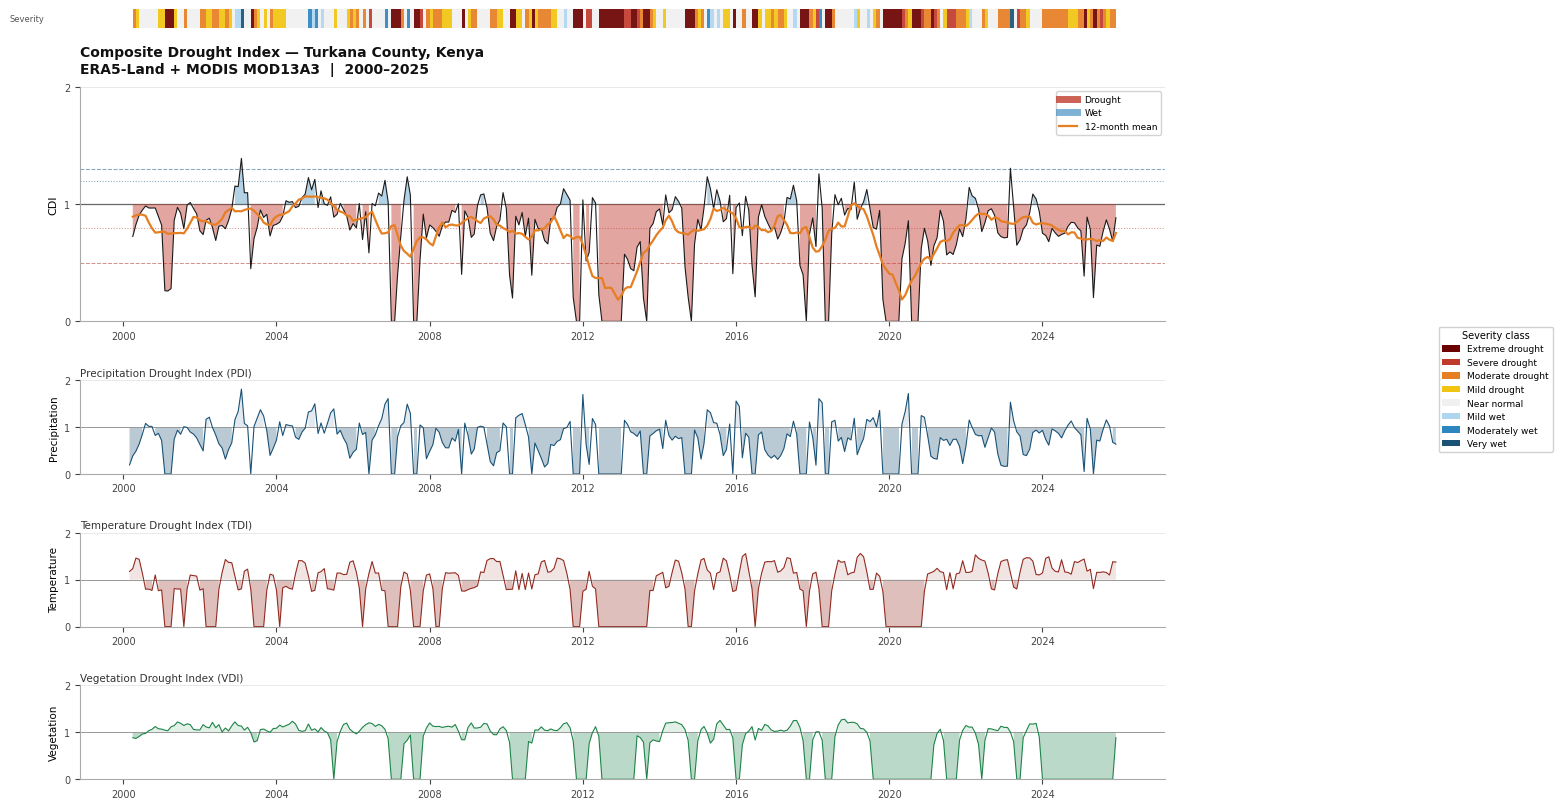

In [10]:
# ── 5.1  Main time-series figure ──────────────────────────────────────────────
from drought_monitoring.plot import plot_timeseries
import matplotlib.pyplot as plt

fig = plot_timeseries(
    df,
    title    = "Composite Drought Index — Turkana County, Kenya",
    subtitle = "ERA5-Land + MODIS MOD13A3  |  2000–2025",
    show_components   = True,    # show PDI, TDI, VDI sub-panels
    show_severity_bar = True,    # coloured severity stripe at top
)
fig.savefig("CDI_timeseries_Turkana.png", dpi=150, bbox_inches="tight")
plt.show()

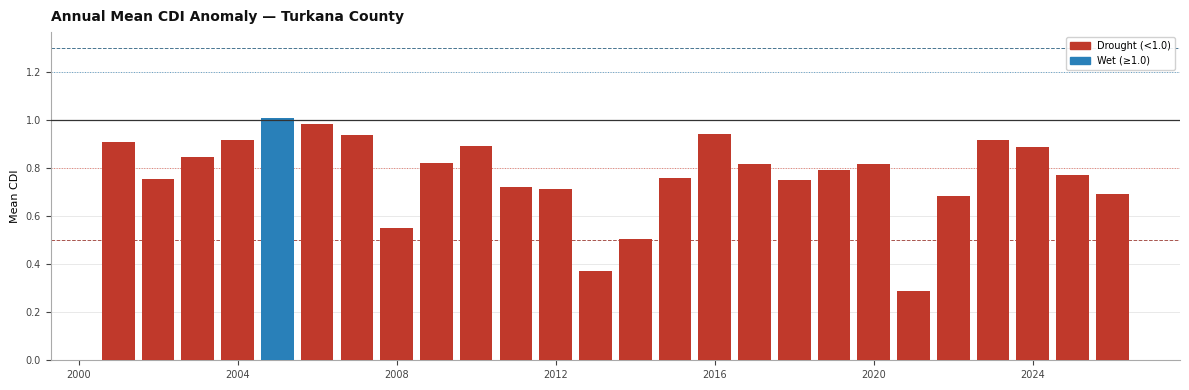

In [11]:
# ── 5.2  Annual anomaly bar chart ─────────────────────────────────────────────
from drought_monitoring.plot import plot_anomaly_bars

fig2 = plot_anomaly_bars(
    df,
    column = "CDI",
    freq   = "Y",    # Y=annual  Q=seasonal  M=monthly
    title  = "Annual Mean CDI Anomaly — Turkana County",
)
fig2.savefig("CDI_annual_Turkana.png", dpi=150, bbox_inches="tight")
plt.show()

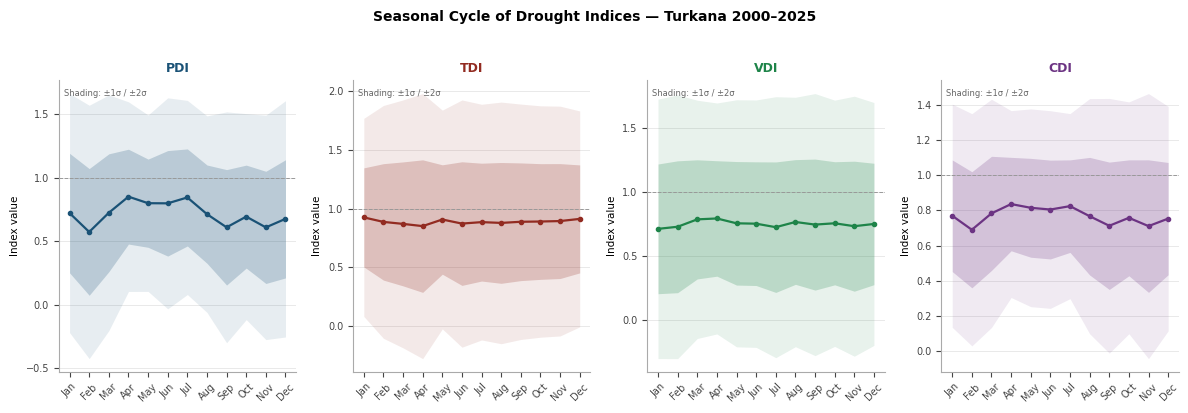

In [12]:
# ── 5.3  Seasonal cycle ───────────────────────────────────────────────────────
from drought_monitoring.plot import plot_seasonal_cycle

fig3 = plot_seasonal_cycle(
    df,
    title = "Seasonal Cycle of Drought Indices — Turkana 2000–2025",
)
fig3.savefig("CDI_seasonal_Turkana.png", dpi=150, bbox_inches="tight")
plt.show()

# QUESTIONS TO DISCUSS:
# 1. In which months is Turkana most drought-prone?
# 2. What does the wide ±2σ envelope on PDI tell you?
# 3. Why is the TDI seasonal signal so flat?

---
## Part 6 · Spatial Maps and Cloud Optimized GeoTIFF Export

In [13]:
# ── 6.1  Compute annual spatial CDI maps ──────────────────────────────────────
# yearly_drought_maps uses xee + dask for memory-efficient pixel-wise CDI.
# Nothing is written to disk at this stage — it all lives in memory as xr.Dataset.

from drought_monitoring.gee import yearly_drought_maps

print("Computing annual CDI maps (dask-parallel, may take 1–3 min)...")
ds = yearly_drought_maps(aoi, start_year=2000, end_year=2025)

print("\nDataset structure:")
print(ds)
print(f"\nDimensions: {dict(ds.dims)}")
print(f"Variables:  {list(ds.data_vars)}")

Computing annual CDI maps (dask-parallel, may take 1–3 min)...


/Users/georgeodero/drought_monitoring/drought_monitoring/gee.py:523: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/Users/georgeodero/drought_monitoring/drought_monitoring/gee.py:577: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(



Dataset structure:
<xarray.Dataset> Size: 666kB
Dimensions:  (time: 26, lon: 20, lat: 40)
Coordinates:
  * time     (time) datetime64[ns] 208B 2000-12-31 2001-12-31 ... 2025-12-31
  * lon      (lon) float64 160B 34.55 34.65 34.75 34.85 ... 36.25 36.35 36.45
  * lat      (lat) float64 320B 1.55 1.65 1.75 1.85 1.95 ... 5.15 5.25 5.35 5.45
Data variables:
    PDI      (time, lon, lat) float64 166kB 0.8063 0.7591 ... 0.8773 0.8696
    TDI      (time, lon, lat) float64 166kB 0.7182 0.8099 0.7404 ... 1.169 1.159
    VDI      (time, lon, lat) float64 166kB 1.122 1.142 0.558 ... 0.3924 0.385
    CDI      (time, lon, lat) float64 166kB 0.8835 0.8828 ... 0.8291 0.8208

Dimensions: {'time': 26, 'lon': 20, 'lat': 40}
Variables:  ['PDI', 'TDI', 'VDI', 'CDI']


/var/folders/tf/9qxxbg0d70qd569tqtkgf6100000gn/T/ipykernel_82232/1499633591.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nDimensions: {dict(ds.dims)}")


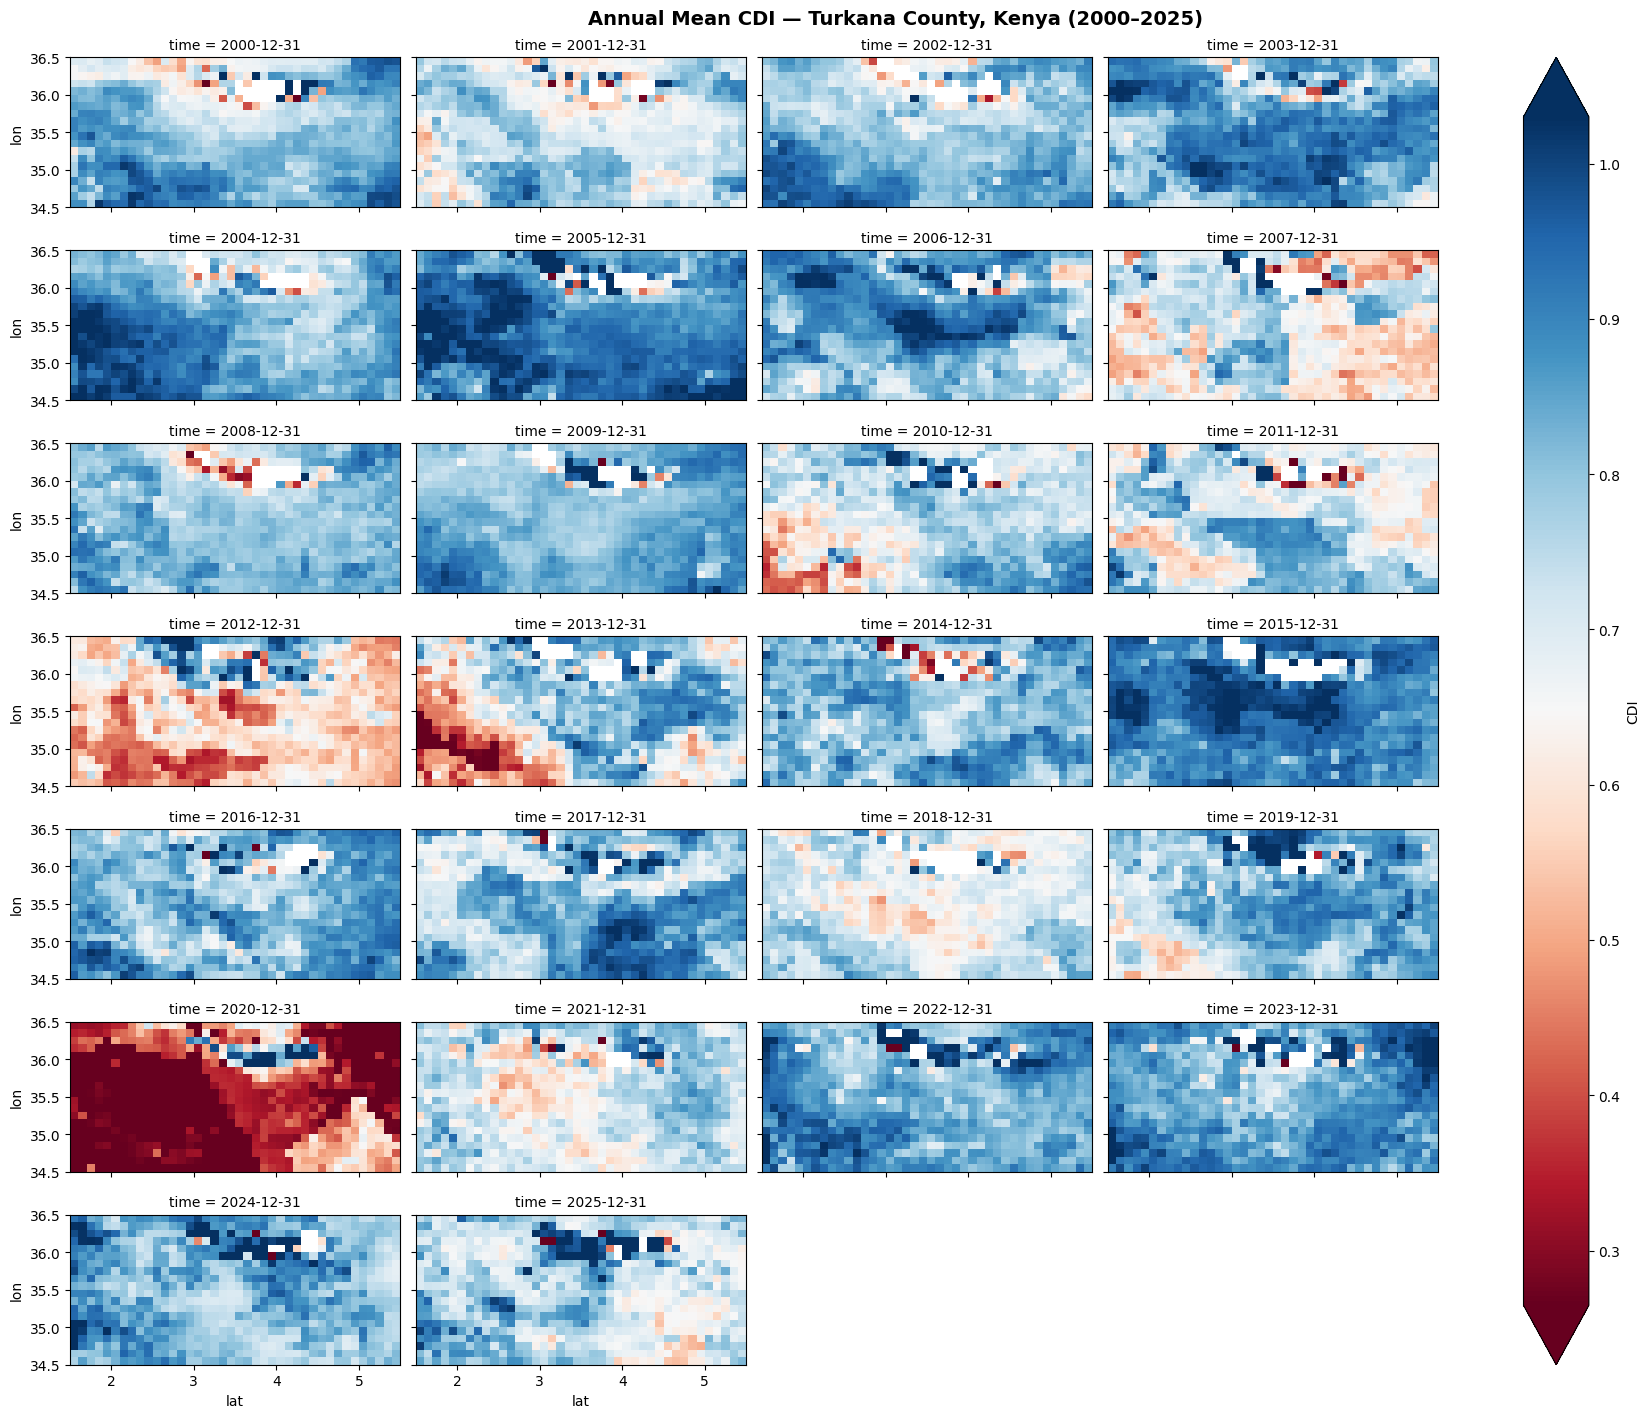

In [14]:
# ── 6.2  Quick matplotlib plot of all years ────────────────────────────────────
import matplotlib.pyplot as plt

ds["CDI"].plot(
    col      = "time",
    col_wrap = 4,
    cmap     = "RdBu",
    robust   = True,
    figsize  = (18, 14),
)
plt.suptitle("Annual Mean CDI — Turkana County, Kenya (2000–2025)",
             y=1.01, fontsize=14, fontweight="bold")
plt.savefig("CDI_annual_maps.png", dpi=120, bbox_inches="tight")
plt.show()

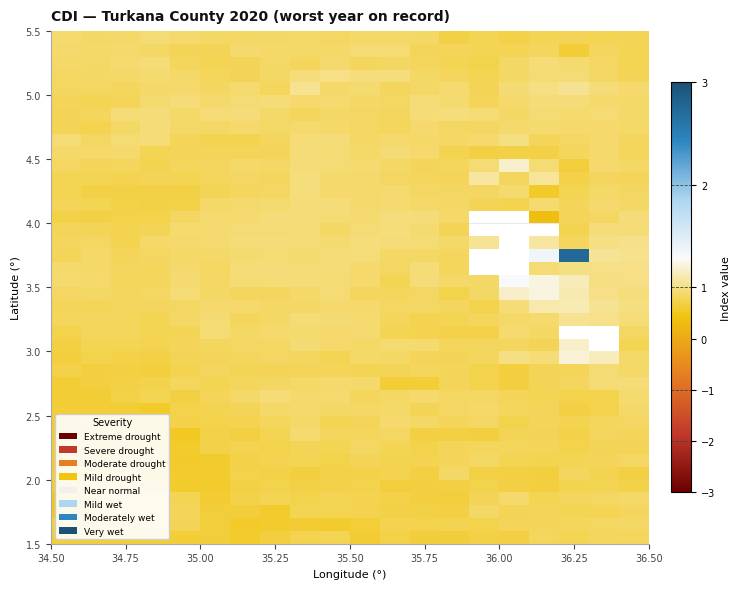

In [15]:
# ── 6.3  Snapshot of worst year (2020) ────────────────────────────────────────
from drought_monitoring.plot import plot_map_snapshot

fig_map = plot_map_snapshot(
    ds["CDI"].sel(time="2020", method="nearest"),
    title  = "CDI — Turkana County 2020 (worst year on record)",
)
plt.show()

In [16]:
# ── 6.4  Export to Cloud Optimized GeoTIFFs ───────────────────────────────────
# One COG per variable — one band per year — ISO date as band description.
# These can be streamed directly in leafmap without any conversion.

import os
from drought_monitoring.io import cdi_stack_to_cog

os.makedirs("outputs", exist_ok=True)

paths = cdi_stack_to_cog(
    ds,
    output_dir = "outputs/",
    prefix     = "Turkana_2000_2025",
)

print("COG files written:")
for var, path in paths.items():
    size_mb = os.path.getsize(path) / 1_048_576
    print(f"  {var}: {path}  ({size_mb:.2f} MB)")

✓ COG written → outputs/Turkana_2000_2025_PDI.tif  (26 bands, 40×20 px, 0.20 MB)
✓ COG written → outputs/Turkana_2000_2025_TDI.tif  (26 bands, 40×20 px, 0.20 MB)
✓ COG written → outputs/Turkana_2000_2025_VDI.tif  (26 bands, 40×20 px, 0.21 MB)
✓ COG written → outputs/Turkana_2000_2025_CDI.tif  (26 bands, 40×20 px, 0.20 MB)
COG files written:
  PDI: /Users/georgeodero/drought_monitoring/workshop/outputs/Turkana_2000_2025_PDI.tif  (0.20 MB)
  TDI: /Users/georgeodero/drought_monitoring/workshop/outputs/Turkana_2000_2025_TDI.tif  (0.20 MB)
  VDI: /Users/georgeodero/drought_monitoring/workshop/outputs/Turkana_2000_2025_VDI.tif  (0.21 MB)
  CDI: /Users/georgeodero/drought_monitoring/workshop/outputs/Turkana_2000_2025_CDI.tif  (0.20 MB)


In [18]:
# ── 6.5  Visualise in leafmap ─────────────────────────────────────────────────
import base64, folium, rasterio
import numpy as np
import matplotlib.pyplot as plt
import leafmap.foliumap as leafmap
from io import BytesIO
from PIL import Image

CARTO      = "https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png"
CARTO_ATTR = "Map tiles by CARTO, CC BY 3.0. Data by OpenStreetMap, ODbL."

def cog_band_to_overlay(tif_path, band=0, vmin=-2.0, vmax=2.0,
                         cmap_name="RdBu", opacity=0.75):
    """Read one band from a COG and return a base64 folium ImageOverlay."""
    with rasterio.open(tif_path) as src:
        data   = src.read(band).astype(float)
        bounds = src.bounds
        if src.nodata is not None:
            data[data == src.nodata] = np.nan

    norm = np.clip((data - vmin) / (vmax - vmin), 0, 1)
    cmap = plt.get_cmap(cmap_name)
    rgba = (cmap(norm) * 255).astype(np.uint8)
    rgba[np.isnan(data), 3] = 0           # transparent where nodata

    buf = BytesIO()
    Image.fromarray(rgba, mode="RGBA").save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()

    overlay = folium.raster_layers.ImageOverlay(
        image   = f"data:image/png;base64,{b64}",
        bounds  = [[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
        opacity = opacity,
        name    = f"Band {band}",
    )
    return overlay, bounds

m = leafmap.Map(center=[3.5, 35.5], zoom=7, tiles=CARTO, attr=CARTO_ATTR)
overlay, bounds = cog_band_to_overlay(str(paths["CDI"]), band=1)
overlay.add_to(m)
folium.LayerControl().add_to(m)
m

---
## Part 7 · 6-Month Drought Forecast

Since MODIS NDVI has no operational forecast product, we model all four indices statistically using:
- **STL decomposition** — separates trend + seasonal + remainder
- **SARIMA(1,0,0)(1,0,0)[12]** — models the seasonal remainder
- **Bootstrap (300 draws)** — builds 90% confidence bands

For VDI specifically, the forecast pipeline is: raw NDVI → STL+SARIMA forecast → convert back to VDI using the full historical LTM. This preserves correct calibration.

In [19]:
# ── 7.1  Run the forecast ─────────────────────────────────────────────────────
from drought_monitoring.forecast import forecast_all_statistical

fc = forecast_all_statistical(
    precip,
    temp,
    ndvi,
    n_months = 6,
    weights  = (0.50, 0.25, 0.25),
    ci_level = 0.90,           # 90% confidence bands
)

print("Forecast output:")
print(fc[["PDI","TDI","VDI","CDI","CDI_lower","CDI_upper","lead"]].round(3))

Forecast output:
              PDI    TDI    VDI    CDI  CDI_lower  CDI_upper  lead
2026-01-01  0.444  1.398  0.817  0.776      0.610      1.166     1
2026-02-01  0.955  1.404  1.046  1.090      0.481      1.707     2
2026-03-01  0.000  1.167  0.798  0.491      0.291      1.447     3
2026-04-01  0.000  0.857  0.864  0.430      0.200      1.068     4
2026-05-01  0.000  0.000  0.000  0.000      0.000      0.823     5
2026-06-01  0.934  0.791  0.000  0.665      0.395      0.965     6


In [20]:
# ── 7.2  Classify forecasted CDI ──────────────────────────────────────────────
fc["severity"] = classify_cdi(fc["CDI"])
print("Forecasted drought severity (next 6 months):")
print(fc[["CDI","severity","CDI_lower","CDI_upper"]].round(3).to_string())

Forecasted drought severity (next 6 months):
              CDI          severity  CDI_lower  CDI_upper
2026-01-01  0.776  Moderate drought      0.610      1.166
2026-02-01  1.090       Near normal      0.481      1.707
2026-03-01  0.491   Extreme drought      0.291      1.447
2026-04-01  0.430   Extreme drought      0.200      1.068
2026-05-01  0.000   Extreme drought      0.000      0.823
2026-06-01  0.665  Moderate drought      0.395      0.965


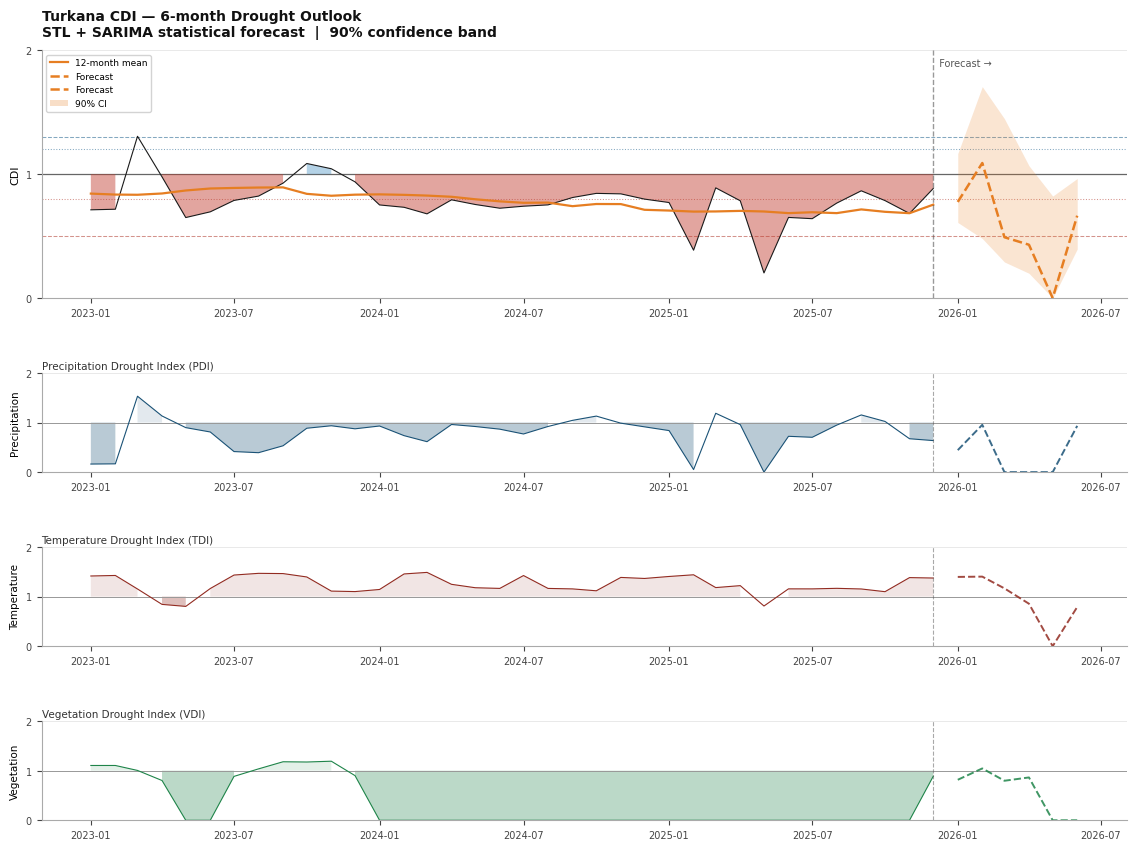

In [21]:
# ── 7.3  Forecast plot ────────────────────────────────────────────────────────
from drought_monitoring.plot import plot_forecast

fig_fc = plot_forecast(
    history   = df,
    forecast  = fc,
    n_history = 36,            # show last 3 years of history
    title     = "Turkana CDI — 6-month Drought Outlook",
    subtitle  = "STL + SARIMA statistical forecast  |  90% confidence band",
    show_components = True,
)
fig_fc.savefig("CDI_forecast_Turkana.png", dpi=150, bbox_inches="tight")
plt.show()

# The orange dashed line is the point forecast.
# The shaded region is the 90% confidence band from the bootstrap.
# The vertical dashed line marks the boundary between history and forecast.

---
## Part 8 · VDI-only forecast (just from NDVI)

If you only have the NDVI series (no precip/temp), you can still forecast VDI:

In [22]:
# ── 8.1  Forecast VDI directly from the NDVI you fetched earlier ──────────────
from drought_monitoring.forecast import forecast_vdi_from_ndvi

vdi_fc = forecast_vdi_from_ndvi(
    ndvi,
    n_months = 6,
    window   = 3,
    ci_level = 0.90,
)

print("VDI forecast (next 6 months):")
print(vdi_fc.round(3))

VDI forecast (next 6 months):
              VDI  VDI_lower  VDI_upper  lead
2026-01-01  0.817      0.821      1.137     1
2026-02-01  1.046      0.770      1.238     2
2026-03-01  0.798      0.000      1.112     3
2026-04-01  0.864      0.000      0.954     4
2026-05-01  0.000      0.000      0.795     5
2026-06-01  0.000      0.000      0.922     6


---
## Part 9 · Hands-On Exercise

### Task: Compute the CDI for a different Kenyan county and compare it to Turkana

1. Choose a different AOI from the list in cell 1.2 (or define your own)
2. Fetch data for 2000–2025
3. Compute `compute_all()` and save to a DataFrame called `df_your_county`
4. Answer these questions:
   - What was the worst drought year in your county?
   - Does the seasonal cycle look different from Turkana?
   - Is the ±2σ envelope on PDI wider or narrower than Turkana?
5. **Bonus**: Run `forecast_all_statistical()` and plot the 6-month outlook

Use the cells below to work through the exercise.

In [23]:
# ── EXERCISE WORKSPACE ────────────────────────────────────────────────────────

# Step 1: Define your AOI
my_aoi = [34.6, -0.3, 35.2,  0.2]   # Kisumu — change this!

# Step 2: Fetch data
my_precip = fetch_era5_precip(my_aoi, start_year=2000, end_year=2025)
my_temp   = fetch_era5_temp(my_aoi,   start_year=2000, end_year=2025)
my_ndvi   = fetch_modis_ndvi(my_aoi,  start_year=2000, end_year=2025)

# Step 3: Compute CDI
df_my = compute_all(my_precip, my_temp, my_ndvi)

# Step 4: Find worst year
worst_year = df_my["CDI"].resample("Y").mean().idxmin()
worst_val  = df_my["CDI"].resample("Y").mean().min()
print(f"Worst drought year: {worst_year.year}  (annual CDI = {worst_val:.3f})")

# Step 5: Compare with Turkana
print(f"Turkana worst year CDI:    0.29 (2020)")
print(f"Kisumu worst year CDI: {worst_val:.2f} ({worst_year.year})")

Worst drought year: 2020  (annual CDI = 0.084)
Turkana worst year CDI:    0.29 (2020)
Kisumu worst year CDI: 0.08 (2020)


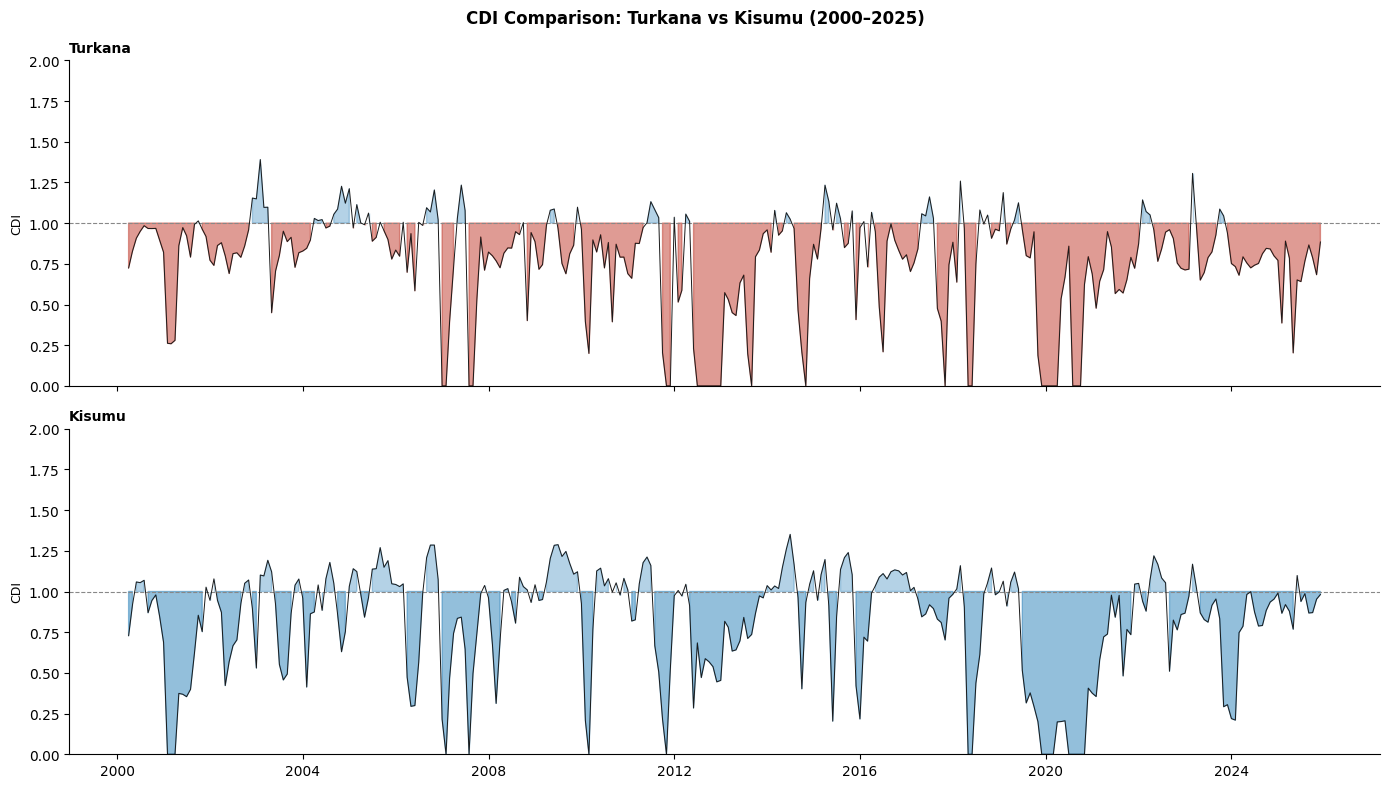

In [24]:
# ── Plot comparison ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, series, label, colour in [
    (axes[0], df["CDI"],    "Turkana",      "#C0392B"),
    (axes[1], df_my["CDI"], "Kisumu",  "#2980B9"),
]:
    ax.axhline(1.0, color="#888", linewidth=0.8, linestyle="--")
    ax.fill_between(series.index, series, 1.0,
                    where=(series < 1.0), color=colour, alpha=0.5, label="Drought")
    ax.fill_between(series.index, series, 1.0,
                    where=(series >= 1.0), color="#2980B9", alpha=0.35, label="Wet")
    ax.plot(series.index, series, color="#1A1A1A", linewidth=0.7)
    ax.set_ylim(0, 2)
    ax.set_ylabel("CDI", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold", loc="left")
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("CDI Comparison: Turkana vs Kisumu (2000–2025)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

---
## Summary

In this workshop you:

| Step | What you did |
|------|--------------|
| 1 | Authenticated with GEE |
| 2 | Fetched ERA5 precipitation, temperature, and MODIS NDVI |
| 3 | Built the CDI formula manually step by step |
| 4 | Used `compute_all()` to compute PDI, TDI, VDI and CDI |
| 5 | Generated time series, anomaly bar, and seasonal cycle plots |
| 6 | Computed annual spatial CDI maps and exported COG GeoTIFFs |
| 7 | Ran a 6-month statistical drought forecast |
| 8 | Compared drought patterns across Kenyan counties |

---

## Resources

- **Package**: https://pypi.org/project/drought-monitoring/
- **GitHub**: https://github.com/geoges/drought-monitoring
- **GEE**: https://code.earthengine.google.com
- **ERA5-Land**: https://cds.climate.copernicus.eu
- **Original CDI paper**: Burchard-Levine et al. (2024) pyCDI, EO-Africa / ESA
- **Contact**: ieee.grss.tuk.sb@gmail.com

---

*Thank you for attending! Questions → oderogeotech@gmail.com*